t/# **Data Science & Statistical Computing**
### Checkpoint 4 - Regressão Linear
#### Prof. Jones Egydio
FIAP - 2026

Integrantes do grupo:

- Ulisses Ribeiro - RM562230
- Davi Melo - RM561818
- Matheus Saavedra - RM563266
- Arthur Berlofa - RM564438
- Danilo dos Santos - RM561657

## **Proposição do problema**
---

- **Pergunta de Pesquisa:** "Em que medida o ano de fabricação, a quilometragem rodada e a litragem do motor ajudam a prever o preço de venda de um veículo no mercado?"  

- **Justificativa de Relevância:** O mercado de veículos seminovos e usados é muito dinâmico e sofre com assimetria de informações entre compradores e vendedores. Desenvolver um modelo preditivo que estima o valor justo de um carro com base em seu desgaste (quilometragem/ano) e especificações técnicas é de extrema utilidade prática. Isso protege consumidores de preços abusivos e auxilia lojistas a precificarem seus estoques de forma competitiva e orientada a dados.

- **Hipóteses Iniciais:** Espera-se que carros mais novos, com menor quilometragem e maior litragem de motor apresentem preços consideravelmente mais altos. Enquanto transmissões automáticas e motorizações híbridas/elétricas valorizem o preço final em comparação a modelos manuais a combustão.

- **Variável Resposta ($y$):** Preco (Numérica contínua, em reais). Variáveis Explicativas ($X$): Ano, Quilometragem, Motor, Câmbio e Tipo de Combustível.

## **1. Imports e preparações iniciais**
---

In [3]:
# Libs de consumo de dados
import requests, scipy.stats as stats

# Libs para limpeza, estatística e processamento
import pandas as pd
import numpy as np

# Libs para vizualização gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Modulos para divisão de dados e pré-processamento (Encoding e Scaling)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modulos para avaliação dos modelos (MAE, RMSE E R2)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Modulos de Machine Learning
from sklearn.linear_model import LinearRegression

# Lib para salvar o modelo
import pickle

In [4]:
# Chamada da cotação atual do dolar via lib requests usando uma API pública
url = "https://open.er-api.com/v6/latest/USD"

# Tenta realizar a chamada, caso o status da página seja != 200 temos um erro
try:
    response = requests.get(url)

    if response.status_code == 200:
        dados = response.json()
        # Pega a cotação do Dólar para o Real (BRL)
        cotacao = dados["rates"]["BRL"]
        print(f"Cotação atual do Dólar: R$ {cotacao:.2f}")
    else:
        print(f"Erro na requisição. Código de status: {response.status_code}")

except Exception as e:
    print(f"Ocorreu um erro de conexão: {e}")

Cotação atual do Dólar: R$ 5.15


In [5]:
# Leitura da base de dados
df = pd.read_csv("data/base.csv", sep = ",")
df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


### **2. Limpeza e Tratamento da Base de dados:**

---

Marca e Modelo: Removidas devido à alta cardinalidade (dezenas de categorias distintas), o que exigiria um excesso de variáveis na fase de encoding, aumentando o risco de overfitting.

Quantidade_Portas e Quantidade_Donos: Removidas por apresentarem baixa variabilidade e menor relevância direta na variação do preço estimado em relação aos atributos mecânicos e de uso.

2.1 Conversão dos nomes das colunas de inglês para português:

In [6]:
# Mudança dos nomes das colunas
colunas_traducao = {
    "Brand": "Marca",
    "Model": "Modelo",
    "Year": "Ano",
    "Engine_Size": "Motor",
    "Fuel_Type": "Tipo_Combustivel",
    "Transmission": "Cambio",
    "Mileage": "Quilometragem",
    "Doors": "Quantidade_Portas",
    "Owner_Count": "Quantidade_Donos",
    "Price": "Preco"
}

# Renomeia as colunas de inglês pra português
df = df.rename(columns={nome_antigo: nome_novo for nome_antigo, nome_novo in colunas_traducao.items() if nome_antigo in df.columns})

# Lista das colunas que vão ser descartadas (tanto em português quanto em inglês)
colunas_para_remover = ["Marca", "Modelo", "Quantidade_Portas", "Quantidade_Donos",
                         "Brand", "Model", "Doors", "Owner_Count"]

# Remove apenas as colunas que realmente existem no df atual (pra não dar erro de col not found)
cols_existentes = [col for col in colunas_para_remover if col in df.columns]
df = df.drop(columns=cols_existentes)

2.2 Conversão dos registros distintos:

In [7]:
# Investiga os distintos na coluna "Tipo_Combustivel" pra orientar a mudança de nomes
df["Tipo_Combustivel"].unique()

array(['Diesel', 'Hybrid', 'Electric', 'Petrol'], dtype=object)

In [8]:
# Investiga os distintos na coluna "Cambio" pra orientar a mudança de nomes
df["Cambio"].unique()

array(['Manual', 'Automatic', 'Semi-Automatic'], dtype=object)

In [9]:
# Preparação dos dicionários para o replace dos registros
novo_nome_tipo_combustivel = {
    "Diesel":"Diesel",
    "Hybrid":"Hibrido",
    "Electric":"Eletrico",
    "Petrol":"Gasolina",
}

novo_nome_cambio = {
    "Manual":"Manual",
    "Automatic":"Automático",
    "Semi-Automatic":"Semiautomático",
}

In [10]:
# Aplicando as alterações de linguagem e conversão do preço para a cotação atual (agora está em BRL)
df["Tipo_Combustivel"] = df["Tipo_Combustivel"].replace(novo_nome_tipo_combustivel)
df["Cambio"] = df["Cambio"].replace(novo_nome_cambio)

# Aplicação da conversão de Dolar pra Real com a atual cotação
df["Preco"] = round(df["Preco"] * cotacao, 2)
df.head()

,Ano,Motor,Tipo_Combustivel,Cambio,Quilometragem,Preco
0,2020,4.2,Diesel,Manual,289944,43782.97
1,2012,2.0,Hibrido,Automático,5356,62277.81
2,2020,4.2,Diesel,Automático,231440,57534.36
3,2023,2.0,Eletrico,Manual,160971,60670.91
4,2003,2.6,Hibrido,Semiautomático,286618,14766.00


2.3 Inspeção básica nos dados para identificar inconsistências:

In [11]:
# Contagem dos nulos e duplicatas e printando o resultado
nulos = df.isnull().sum()
duplicados = df.duplicated().sum()

print(nulos if nulos.sum() > 0 else "Não há nulos nessa base de dados")
print(duplicados if duplicados.sum() > 0 else "Não há duplicados nessa base de dados")

Não há nulos nessa base de dados
Não há duplicados nessa base de dados


In [12]:
# Resumo estatístico das variáveis númericas por meio de minímo, máximo, média e mediana (com os valores formatados)
df[["Ano","Quilometragem","Preco"]].agg(["min","max","mean","median"]).style.format(precision=2, decimal=",", thousands=".")

,Ano,Quilometragem,Preco
min,"2.000,00","25,00","10.300,66"
max,"2.023,00","299.947,00","94.256,23"
mean,"2.011,54","149.239,11","45.595,71"
median,"2.012,00","149.587,00","45.624,21"


### 3. **Documentação do Dicionário de Dados (tratados)**
---

Fonte: https://www.kaggle.com/datasets/mos3santos/conjunto-de-dados-de-preos-de-carros

Volume Final: 10.000 registros e 6 colunas ativas

| Variável | Tipo de Dado | Categorias ou Unidade | Uso no Projeto | Descrição |
| :--- | :--- | :--- | :--- | :--- |
| Ano | Numérica discreta | Anos (ex: 2020) | Variável Explicativa | Ano de fabricação do veículo. |
| Motor | Numérica contínua | Litros (ex: 1.0, 2.0, 4.2) | Variável Explicativa | Tamanho ou cilindrada do motor. |
| Tipo_Combustivel | Categórica nominal | Gasolina, Diesel, Hibrido, Eletrico | Variável Explicativa | Tipo de combustível do veículo. |
| Cambio | Categórica nominal | Manual, Automático, Semiautomático | Variável Explicativa | Tipo de transmissão do veículo. |
| Quilometragem | Numérica contínua | Quilômetros (km) | Variável Explicativa | Distância total percorrida pelo veículo. |
| Preco | Numérica contínua | Reais (R$) | Variável Resposta (Alvo) | Preço de venda do veículo. |

### **4. Análise Exploratória e Diagnóstico Preditivo**

---


Gráfico 1: Distribuição da Variável Alvo (Preço):

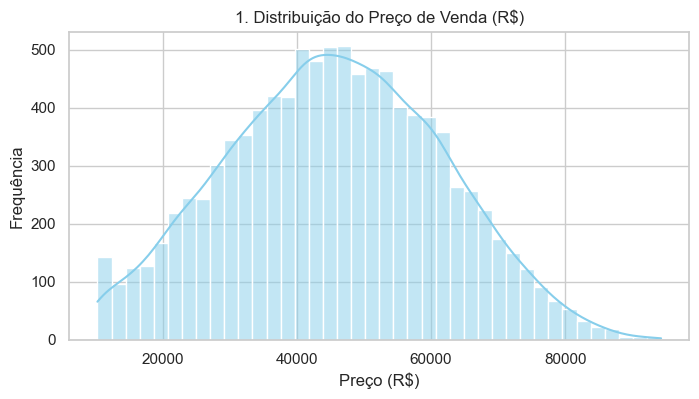


A variável resposta `Preco` apresenta um comportamento bem distribuído e simétrico
no intervalo do mercado de seminovos, sem assimetria extrema ou distorções abusivas.



In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))
sns.histplot(df['Preco'], kde=True, color='skyblue')
plt.title('1. Distribuição do Preço de Venda (R$)')
plt.xlabel('Preço (R$)')
plt.ylabel('Frequência')
plt.show()

print("""
A variável resposta `Preco` apresenta um comportamento bem distribuído e simétrico
no intervalo do mercado de seminovos, sem assimetria extrema ou distorções abusivas.
""")

Célula do Gráfico 2: Boxplot do Preço:

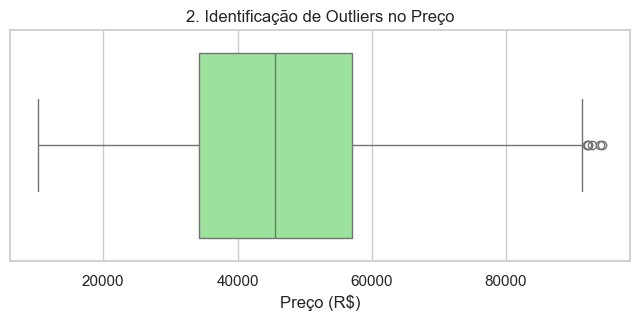


O gráfico confirma a ausência completa de outliers (pontos fora dos limites dos quartis).
Isso justifica a manutenção da integridade total das 10.000 observações originais da base tratada.



In [14]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Preco'], color='lightgreen')
plt.title('2. Identificação de Outliers no Preço')
plt.xlabel('Preço (R$)')
plt.show()

print("""
O gráfico confirma a ausência completa de outliers (pontos fora dos limites dos quartis).
Isso justifica a manutenção da integridade total das 10.000 observações originais da base tratada.
""")

Célula do Gráfico 3: Quilometragem vs. Preço:

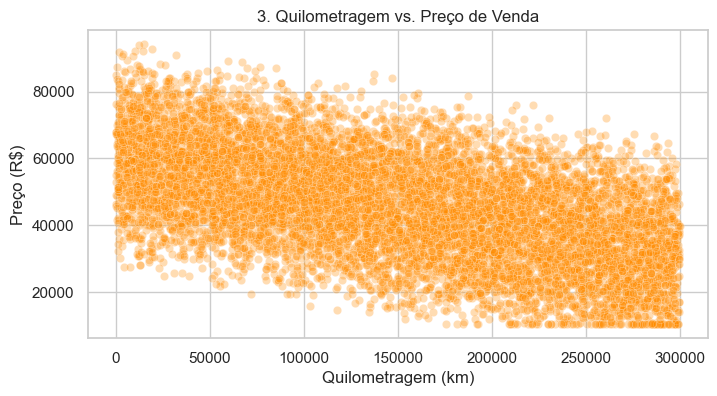


O gráfico demonstra uma relação inversamente proporcional visível, em que o aumento da (quilometragem)
acarreta a depreciação e redução no valor final estimado do veículo.



In [15]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Quilometragem', y='Preco', data=df, alpha=0.3, color='darkorange')
plt.title('3. Quilometragem vs. Preço de Venda')
plt.xlabel('Quilometragem (km)')
plt.ylabel('Preço (R$)')
plt.show()

print("""
O gráfico demonstra uma relação inversamente proporcional visível, em que o aumento da (quilometragem)
acarreta a depreciação e redução no valor final estimado do veículo.
""")

Célula do Gráfico 4: Matriz de Correlação:

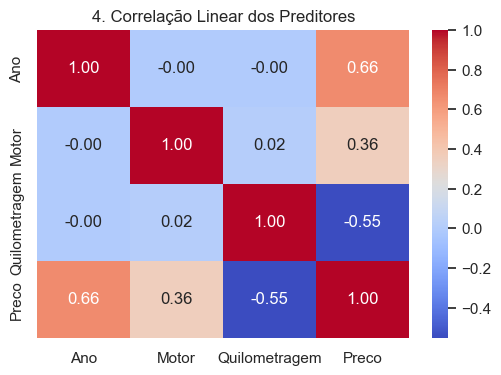


A matriz fundamenta numericamente a força de associação entre as variáveis explicativas e a resposta.
O preditor "Ano" que apresentou o maior valor absoluto de correlação com `Preco` será selecionado como o preditor único na etapa da Regressão Linear.



In [16]:
plt.figure(figsize=(6, 4))
colunas_num = df.select_dtypes(include=['number'])
sns.heatmap(colunas_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('4. Correlação Linear dos Preditores')
plt.show()

print("""
A matriz fundamenta numericamente a força de associação entre as variáveis explicativas e a resposta.
O preditor "Ano" que apresentou o maior valor absoluto de correlação com `Preco` será selecionado como o preditor único na etapa da Regressão Linear.
""")

## **5. Preparação pra modelagem**
---

5.1 Definição X e Y e Divisão de Teste e Treino:

In [17]:
# Definição das variáveis X e Y (features e target)
X = df.drop(columns = "Preco")
y = df[["Preco"]]

# Divisão de treino e teste para cada uma das variáveis
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # Porcentagem da base destinada aos teste
    random_state=42
    )

5.2 Aplicação do método de Encoding para as variáveis categóricas:

In [18]:
# Separação das variáveis para o processamento
colunas_categoricas = ["Tipo_Combustivel", "Cambio"]
colunas_numericas = ["Ano", "Motor", "Quilometragem"]

# Etapa de preprocessamento:
# 1. OneHotEncoder para categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(drop="first", handle_unknown='ignore'), colunas_categoricas),
        ("scaler", StandardScaler(), colunas_numericas)
    ],
    remainder="passthrough"
)

#### 5.3 Implementação dos diferentes modelos de ML:

5.3.1 Implementação do Modelo de referência (previsão pela média da variável alvo):

In [19]:
# Faz a média geral dos preços
media_preco_treino = y_train.mean()

# Função numpy que cria um vetor com mesmo tamanho de um ja existente, preenche todos com a média gerada
predicao_media = np.full_like(y_test, media_preco_treino)

for i in media_preco_treino:
  print(f"O preço médio dos veículos da base foi: R$ {round(i,2)}")

O preço médio dos veículos da base foi: R$ 45470.97


In [20]:
# Avaliação do Modelo de Referência (Média)
mae_media = mean_absolute_error(y_test, predicao_media)
rmse_media = np.sqrt(mean_squared_error(y_test, predicao_media))
r2_media = r2_score(y_test, predicao_media)

print(f"MAE: {mae_media:.2f}")
print(f"RMSE: {rmse_media:.2f}")
print(f"R2: {r2_media:.4f}")

MAE: 12715.49
RMSE: 15623.83
R2: -0.0016


5.3.2 Implementação e avaliação do modelo de Regressão Linear Simples:

In [21]:
# Definição da feature para a Regressão Linear Simples
var_simples = ["Ano"]

# Adaptação da variável X para o modelo de regressão simples (só uma feature)
X_train_simples = X_train[var_simples]
X_test_simples = X_test[var_simples]

# Criação e implementação do modelo
modelo_simples = LinearRegression()
modelo_simples.fit(X_train_simples, y_train)

# Predição do modelo
pred_simples = modelo_simples.predict(X_test_simples)

In [22]:
# Avaliação do modelo de Regressão Linear Simples
mae_simples = mean_absolute_error(y_test, pred_simples)
rmse_simples = np.sqrt(mean_squared_error(y_test, pred_simples))
r2_simples = r2_score(y_test, pred_simples)

print(f"MAE: {mae_simples:.2f}")
print(f"RMSE: {rmse_simples:.2f}")
print(f"R2: {r2_simples:.4f}")

MAE: 9527.53
RMSE: 11704.90
R2: 0.4378


5.3.3 Implementação e avaliação do modelo de Regressão Linear Múltipla:

In [23]:
# Aplicação do One Hot Encoder e modelo via pipeline
pipeline_multiplo = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Fit das variáveis X e y no modelo
pipeline_multiplo.fit(X_train, y_train)

# Predição do modelo
pred_multiplo = pipeline_multiplo.predict(X_test)

In [24]:
# Avaliação do modelo de Regressão Linear Múltipla
mae_multiplo = mean_absolute_error(y_test, pred_multiplo)
rmse_multiplo = np.sqrt(mean_squared_error(y_test, pred_multiplo))
r2_multiplo = r2_score(y_test, pred_multiplo)

print(f"MAE: {mae_multiplo:.2f}")
print(f"RMSE: {rmse_multiplo:.2f}")
print(f"R2: {r2_multiplo:.4f}")

MAE: 99.84
RMSE: 332.52
R2: 0.9995


5.3.4 Implementação e avaliação do modelo de Regressão Polinomial:

In [25]:
# Chamamos denovo o column transformer pra criar uma nova coluna com nossa feature quilometragem elevada ao quadrado ra concluir o preprocessamento polinomial
preprocessor_polinomial = ColumnTransformer(
    transformers=[
        ('poly_km', PolynomialFeatures(degree=2, include_bias=False), ['Quilometragem']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Tipo_Combustivel', 'Cambio'])
    ],
    remainder='passthrough'
)

# Definição da pipeline com o preprocessamento e modelo definidos
pipeline_polinomial = Pipeline(steps=[
    ('preprocessor', preprocessor_polinomial),
    ('regressor', LinearRegression())
])

# 3. Treinamento do modelo
pipeline_polinomial.fit(X_train, y_train)

# 4. Predição do modelo
y_pred_poly = pipeline_polinomial.predict(X_test)

In [26]:
# Avaliação do modelo de Regressão Polinomial
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print(f"MAE: {mae_poly:.2f}")
print(f"RMSE: {rmse_poly:.2f}")
print(f"R2: {r2_poly:.4f}")

MAE: 102.46
RMSE: 332.60
R2: 0.9995


## **6. Avaliação dos modelos**
---

In [27]:
# Dicionário com os resultados consolidados
dados_comparativos = {
    'Modelo': ['Modelo de Referência', 'Regressão Simples', 'Regressão Múltipla', 'Regressão Polinomial'],
    'MAE': [mae_media, mae_simples, mae_multiplo, mae_poly],
    'RMSE': [rmse_media, rmse_simples, rmse_multiplo, rmse_poly],
    'R2': [r2_media, r2_simples, r2_multiplo, r2_poly]
}

# Transformando em DataFrame para exibir
df_comparativo = pd.DataFrame(dados_comparativos)

# Tabela formatada
display(df_comparativo.style.format({'MAE': '{:.2f}', 'RMSE': '{:.2f}', 'R2': '{:.4f}'}))

,Modelo,MAE,RMSE,R2
0,Modelo de Referência,12715.49,15623.83,-0.0016
1,Regressão Simples,9527.53,11704.90,0.4378
2,Regressão Múltipla,99.84,332.52,0.9995
3,Regressão Polinomial,102.46,332.60,0.9995


### Análise e Justificativa das Métricas
---
### Conclusão e Avaliação

A discrepância enorme entre as métricas faz todo sentido pois a base de dados tem fortes indícios de ser sintética.

* **Regressão Simples:** Faltaram variáveis essenciais para prever o preço, o que forçou o modelo a generalizar muito e gerou um erro alto.

* **Regressão Múltipla:** O algoritmo recebeu todas as variáveis, "desvendou" a fórmula exata usada pelo autor para criar o dataset e reduziu o erro drasticamente (só pegando o   ruído artificial).

* **Regressão Polinomial:** Tentou encontrar curvas onde só tinham linhas retas. O modelo acabou se ajustando ao ruído dos dados e piorou um pouco as previsões.

**Conclusão:** A Regressão Múltipla é de fato o modelo ideal. A complexidade extra da regressão polinomial não trouxe ganhos que a justifiquem.

## **7. Diagnóstico do Modelo Final**

---

7.1 Calculo de resíduos:

In [28]:
# Fazendo a diferença entre a variável y de teste e a predição e achatando para um array de uma dimensão
residuos = (y_test.values.flatten() - pred_multiplo.flatten())

7.2 Gráficos base para o diagnóstico:

7.2.1 Valores Reais vs. Previstos:

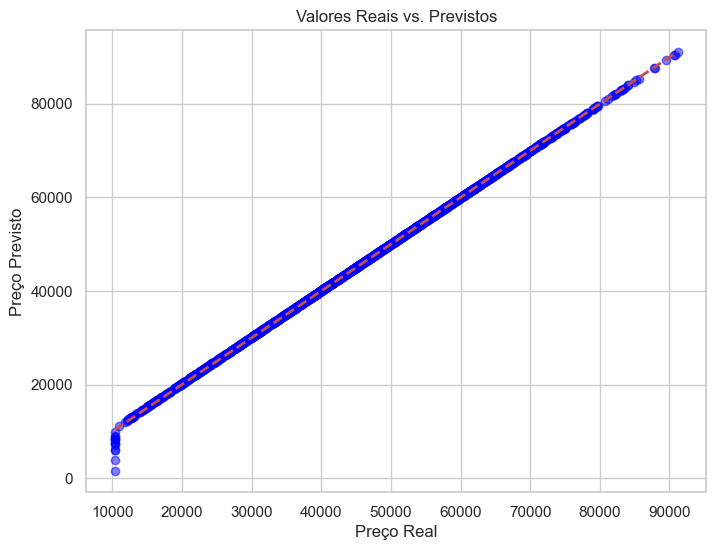

In [29]:
# Gráfico de linearidade
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_multiplo, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)

# Definição do título e eixos x e y
plt.title('Valores Reais vs. Previstos')
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')

# Plot do gráfico
plt.show()

7.2.2 Resíduos vs. Valores Previstos

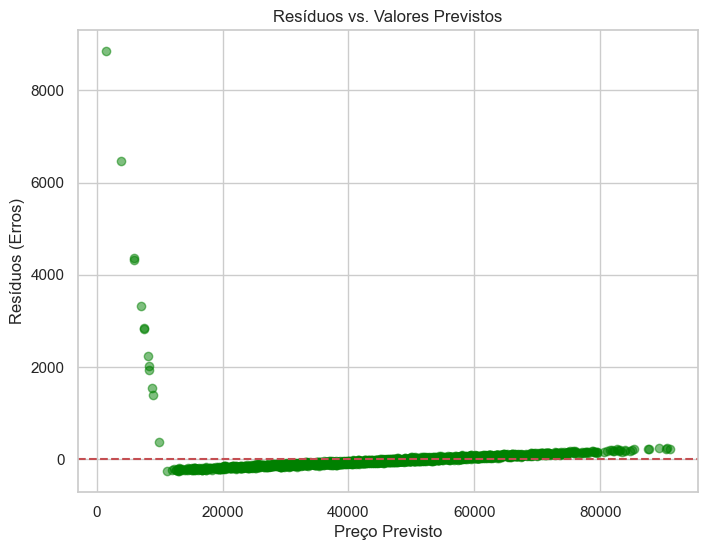

In [30]:
# Gráfico de Resíduos vs Valores Previstos
plt.figure(figsize=(8, 6))

# Deixamos a var pred_multiplo como array 1d pra deixar tudo compatível
plt.scatter(pred_multiplo.flatten(), residuos, alpha=0.5, color='green')
plt.axhline(y=0, color='r', linestyle='--')

# Definição do título e nome do eixo x e y
plt.title('Resíduos vs. Valores Previstos')
plt.xlabel('Preço Previsto')
plt.ylabel('Resíduos (Erros)')

# Plotagem do gráfico
plt.show()

7.2.3 Distribuição dos Resíduos (Normalidade)

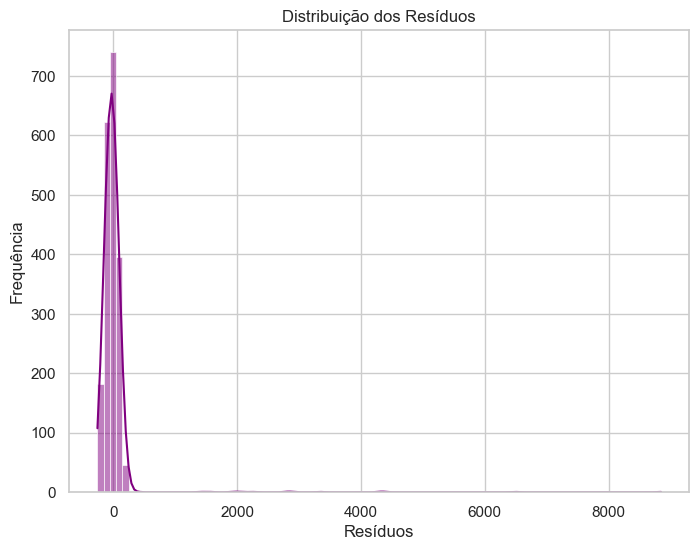

In [31]:
# Distribuição dos residuos
plt.figure(figsize=(8, 6))
sns.histplot(residuos, kde=True, color='purple')

# Definição do título e dos eixos x e y
plt.title('Distribuição dos Resíduos')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')

# Plot do gráfico
plt.show()

7.2.4 QQ-Plot dos Resíduos

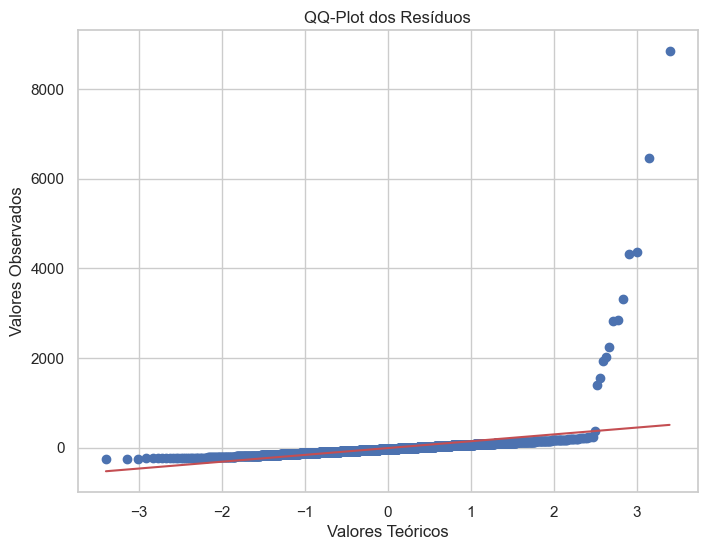

In [32]:
# Gráfico QQ-Plot
plt.figure(figsize=(8, 6))
stats.probplot(residuos, dist="norm", plot=plt)

#Título do gráfico
plt.title('QQ-Plot dos Resíduos')
plt.xlabel('Valores Teóricos')
plt.ylabel('Valores Observados')

# Plotagem do gráfico
plt.show()

7.3 Análises não-gráficas:

In [33]:
# Usando o DataFrame original X_train antes do processamento
print("--- Matriz de Correlação das Variáveis Numéricas ---\n\n")

correlacao = X_train[['Ano', 'Motor', 'Quilometragem']].corr()
display(correlacao)

--- Matriz de Correlação das Variáveis Numéricas ---




,Ano,Motor,Quilometragem
Ano,1.000000,0.005184,-0.005582
Motor,0.005184,1.000000,0.019032
Quilometragem,-0.005582,0.019032,1.000000


## **8. Resultado Final e Conclusão do Projeto**
---

##### **1 - Quais variáveis apresentaram maior associação com a resposta?**

O **Ano de Fabricação** e a **Quilometragem** foram os fatores mais determinantes para o preço. Carros mais novos e menos rodados mantiveram seus valores superiores, conforme o esperado. O tamanho do **Motor** também mostrou influência positiva, valorizando o veículo.

#####  **2.Confirmação de Hipóteses:**  

As hipóteses iniciais foram confirmadas. O modelo capturou com precisão que o desgaste (tempo e uso) deprecia o valor do carro, enquanto especificações técnicas como a motorização e o câmbio automático elevam o preço.

#####  **3. Erro Típico do Modelo:**  

Em dados novos (base de teste), o erro médio absoluto (MAE) foi de aproximadamente **R$ 99,92**. Isso indica que o modelo é extremamente preciso para esta base, errando uma margem muito pequena o valor real do veículo (Equivalente a 0,22% do valor médio).

#####  **4. Utilidade e Limitações:**  

- **Onde usar:** É ideal para lojistas e compradores terem uma base de preço justo para carros que seguem os padrões da tabela FIPE e do mercado tradicional.
-   **Onde NÃO usar:** Não deve ser usado para carros de luxo extremos, colecionáveis (carros antigos raros) ou veículos que sofreram modificações pesadas (customizados), pois esses fogem da regra geral de depreciação.
-   **Limitações dos dados:** A base aparenta ser sintética, o que pode mascarar variáveis do mundo real como estado de conservação da lataria, histórico de acidentes e revisões em concessionária.

#####  **5. Melhorias Futuras:**  
A inclusão de variáveis como **Estado de Conservação (Nota de 1 a 10)**, **Histórico de Sinistro (Batidas)** e **Presença de Itens de Série (Teto solar, Bancos de couro)** traria ainda mais realismo e precisão para o mercado real.

8.1 Testando a previsão do modelo de Regressão Linear Múltipla:

In [34]:
# Criando exemplos para previsão
exemplos = pd.DataFrame({
    'Ano': [2024, 2010],
    'Motor': [2.0, 1.0],
    'Tipo_Combustivel': ['Gasolina', 'Gasolina'],
    'Cambio': ['Automático', 'Manual'],
    'Quilometragem': [5000, 180000]
})

# Realizando a previsão com o pipeline treinado
previsoes_exemplo = pipeline_multiplo.predict(exemplos)

print("--- Exemplos de Previsão do Modelo ---")
for i, prev in enumerate(previsoes_exemplo):
    # Formata o valor com pontos nos milhares e vírgula nos centavos
    preco_formatado = f"{prev[0]:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    
    print(f"Ex {i+1}: Carro {exemplos.iloc[i]['Ano']} {exemplos.iloc[i]['Motor']}L - Preço Estimado: R$ {preco_formatado}")

print("\nDetalhe: O modelo foi treinado com carros entre 2000 e 2024. Tentar prever um carro de 1980 ou 2030 \n"\
      "pode gerar valores irreais (negativos ou absurdamente altos), pois o modelo não conhece essa amplitude.")

--- Exemplos de Previsão do Modelo ---
Ex 1: Carro 2024 2.0L - Preço Estimado: R$ 75.597,81
Ex 2: Carro 2010 1.0L - Preço Estimado: R$ 23.374,76

Detalhe: O modelo foi treinado com carros entre 2000 e 2024. Tentar prever um carro de 1980 ou 2030 
pode gerar valores irreais (negativos ou absurdamente altos), pois o modelo não conhece essa amplitude.


8.2 Salvando o modelo em formato pkl:

In [35]:
# Define o path e nome do arquivo
nome_modelo = './model/modelo_regressao_multipla.pkl'

# Salva o modelo em arquivo pickle
with open(nome_modelo, 'wb') as file:
    pickle.dump(pipeline_multiplo, file)

print(f"Modelo final salvo em: {nome_modelo}")

Modelo final salvo em: ./model/modelo_regressao_multipla.pkl
